In [1]:
from collections import namedtuple
import datetime
import itertools
import json
import os
import requests
import sys

from IPython.core.display import display, HTML
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sb
import scipy
import sklearn

from lib import dataset

%matplotlib inline
%load_ext autoreload
%autoreload 2
plt.style.use("seaborn")
pd.set_option('display.max_columns', 1000)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 500)
display(HTML("<style>.container { width:85% !important; }</style>"))

# Intro

The simplest case to look at is the federal elections. 

The obvious unjust system here is the electoral college. So, according to some algorithm (or multiple), let's try to answer the question:

*Under the electoral college system, how much does each vote count?* 

(In units of 1/N, the total number of voters).

Federal election data by state is avaible [here](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/42MVDX)... for now you'll need to download it manually to the `path` below.

We'll also need estimated annual population data.

In [2]:
data = dataset.get_csv(
    url='https://dataverse.harvard.edu/api/access/datafile/3444051?format=original&gbrecs=true',
    name='presidential_election_results'
)
data.head(3)

Using cached file data/presidential_election_results.csv


,year,state,state_po,state_fips,state_cen,state_ic,office,candidate,party,writein,candidatevotes,totalvotes,version,notes
0,1976,Alabama,AL,1,63,41,US President,"Carter, Jimmy",democrat,False,659170,1182850,20171015,NaN
1,1976,Alabama,AL,1,63,41,US President,"Ford, Gerald",republican,False,504070,1182850,20171015,NaN
2,1976,Alabama,AL,1,63,41,US President,"Maddox, Lester",american independent party,False,9198,1182850,20171015,NaN


In [3]:
party_colors = {'republican': 'darkred', 'democrat': 'blue', 'other': 'gray'}

data.loc[:, 'party_group'] = data['party'].where(data['party'].isin(party_colors), 'other')
data.loc[:, 'party_group_color'] = data['party_group'].map(lambda x: party_colors[x])

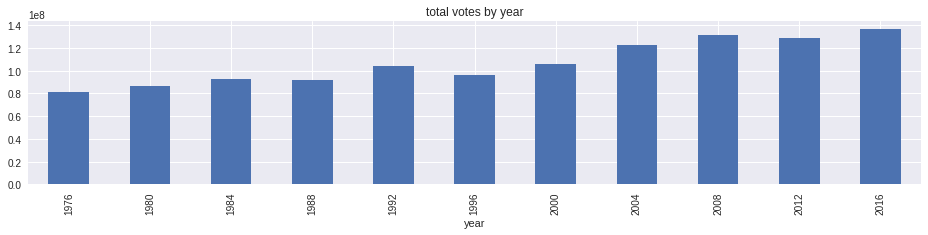

In [4]:
# How many people voted each year?
# TODO: join in number of nonvoters via census data
(data.groupby('year')['candidatevotes'].sum()
     .plot(kind='bar', figsize=(16, 3))
)
plt.title('total votes by year');

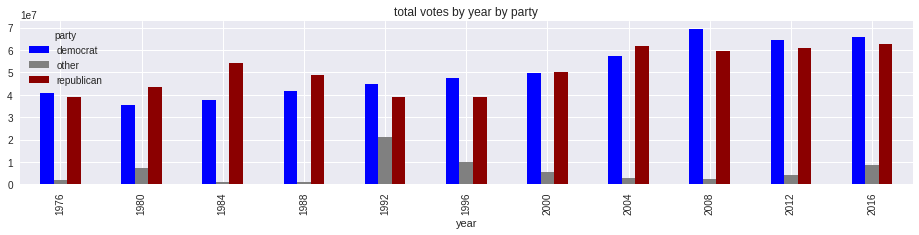

In [5]:
# How many voted for each party?
# TODO: join in number of nonvoters
pivoted = data.pivot_table(
    index='year', 
    columns='party_group', 
    values='candidatevotes', 
    aggfunc='sum'
).rename_axis(columns='party')

pivoted.plot(kind='bar', figsize=(16, 3), color=[party_colors[c] for c in pivoted.columns])
plt.title('total votes by year by party');

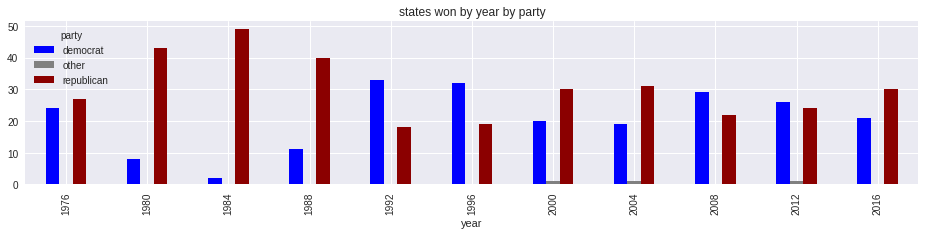

In [14]:
# How many states went for each party?
# Ignoring a couple small idiosyncracies like:
# https://en.wikipedia.org/wiki/Nebraska%27s_2nd_congressional_district
# Hack to get largest row in each group...
(data.sort_values('candidatevotes', ascending=False)
     .groupby(['year', 'state'])
     ['party_group'].first()
     .reset_index()
     .pivot_table(
         index='year',
         columns='party_group',
         values='state',
         aggfunc='count'
     )
     .fillna(0)
     .rename_axis(columns='party')
     .plot(
         kind='bar', 
         figsize=(16, 3), 
         color=[party_colors[c] for c in pivoted.columns],
         title='states won by year by party'
     )
);

We'll get population data from the annual estimated census population data [here](https://api.census.gov/data.html). You'll need an API key [here](https://api.census.gov/data/key_signup.html), then restart your container and pass it into the environment as `CENSUS_API_KEY`.

https://api.census.gov/data/2018/pep/population?get=GEONAME,POP&for=state:*&key=YOUR_KEY_GOES_HERE	

Skipping this for now...

In [6]:
CENSUS_API_KEY = os.getenv('CENSUS_API_KEY')

# Fairness Criteria

How do we measure how fair an election or a voting system turned out to be?

- https://en.wikipedia.org/wiki/First-past-the-post_voting good guide
- https://en.wikipedia.org/wiki/Wasted_vote
- For presidential elections, we want to think about:
  - consider the electoral college
  - plurality system (will need approximate data on second-preferences)
  - counts of supposed nonvoters due to their votes being wasted
  - estimates of counts of tactical voters
  - weighting of swing states